# 1. Loading

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
# from pprint import pprint
from datetime import timedelta, datetime
import gnss_lib_py as glp
# from gnss_lib_py.utils.ephemeris_downloader import load_ephemeris
from astropy.time import Time # datetime to TAI
import plotly.graph_objects as go
from collections import defaultdict

# from dataclasses import dataclass
# from pymap3d import eci2ecef
# from src.conversions import eci_to_ecef
from astropy.coordinates import get_body, ITRS
from lunarsky import MCMF
from astropy import units as u

from src.lugre_parser import get_unique_timestamps, lugre_parser, get_unique_times, gps_seconds_to_gps_weeks, get_const_band



In [2]:
import pylupnt as pnt

Downloaded data to LuPNT_data


In [3]:
plt.rcdefaults()

## 1.1 Importing Data

In [4]:
data_path = Path().joinpath("LuGRE Mission Data/L0/TLM/")
set_ids = get_unique_timestamps(data_path) # get all unique timestamps in the directory

# shrink set_ids to the ones on lunar surface
surface_ids = [set_id for set_id in set_ids if "_S_" in set_id]
print(len(surface_ids), "surface data sets found")


datasets = [lugre_parser(data_path, set_id) for set_id in surface_ids]

7 surface data sets found


/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning: errors='ignore

In [5]:
print([datasets[0][i].columns for i in datasets[0].keys()])

[Index(['date', 'time', 'duration', 'phase', 'opnumber', 'index'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'signalId', 'svid', 'doppler',
       'codePhase', 'acfCorr', 'noiseFloor', 'acqMode', 'CN0'],
      dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'appName', 'wn', 'tow', 'decimals',
       'nSat', 'posX', 'posY', 'posZ', 'velX', 'velY', 'velZ', 'posStd',
       'velStd', 'timStd', 'clockBias', 'clockDrift', 'ggto', 'GDOP', 'PDOP',
       'HDOP', 'VDOP', 'TDOP'],
      dtype='object'), Index(['rxTime', 'signal', 'svId', 'Toe', 'Toc', 'iodNav', 'iodE', 'iodC'], dtype='object'), Index(['Receiver Time [s]', 'Clock Bias [m]', 'ClockDrift [m/s]'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'measures', 'svid', 'prRaw', 'cn0',
       'signalId', 'fdRaw', 'accDoppler', 'fdRateRaw'],
      dtype='object')]


In [59]:
dataset_id = 5
lugre_df = datasets[dataset_id]
nav = lugre_df["nav"]

rx_ecef_km = nav[["posX", "posY", "posZ"]].to_numpy() / 1000.0

## 1.2 Time Transforms

In [ ]:
gps_time_s = nav["rxTime"].to_numpy()
utc_times: list[datetime] = [ glp.gps_millis_to_datetime(t*1000) for t in gps_time_s ]
utc_floats_s = [ t.timestamp() for t in utc_times ]

# Time for Astropy
t_ast = Time(utc_times, scale='utc')
# GCRS to ITRS (ECEF)
moon_gcrs = get_body("moon", t_ast)
moon_itrs = moon_gcrs.transform_to(ITRS(obstime=t_ast))

# Extract as km for plotting
moon_ecef_km = np.column_stack([
    moon_itrs.x.to(u.km).value,
    moon_itrs.y.to(u.km).value,
    moon_itrs.z.to(u.km).value
])


In [98]:
# GPS Weeks
gps_week_start, sec_into_week_start = gps_seconds_to_gps_weeks(gps_time_s[0])
gps_week_end, sec_into_week_end = gps_seconds_to_gps_weeks(gps_time_s[-1])
print(f"Start: Week {gps_week_start}, {sec_into_week_start}s\nEnd: Week {gps_week_end}, {sec_into_week_end}s")


Start: Week 2358, 75248.43583989143s
End: Week 2358, 78698.43583989143s


# 2. Initial Plots

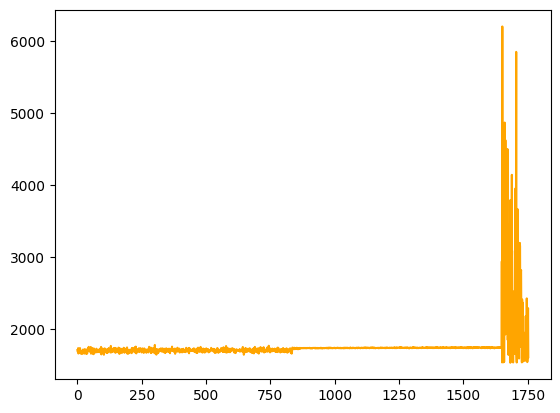

In [86]:
# Moon radius check
distances = rx_ecef_km - moon_ecef_km
distances = np.apply_along_axis(np.linalg.norm, 1, distances)
# print(distances)
# plt.axhline( 1.7374e3, color='b')
plt.plot(distances, color='orange')
# plt.ylim(1.5e3,3.5e3)
plt.show()

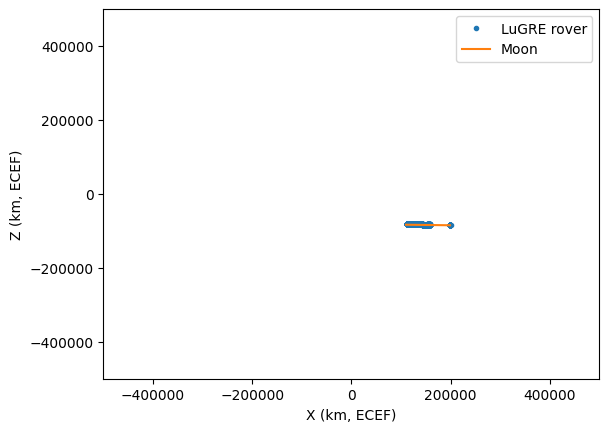

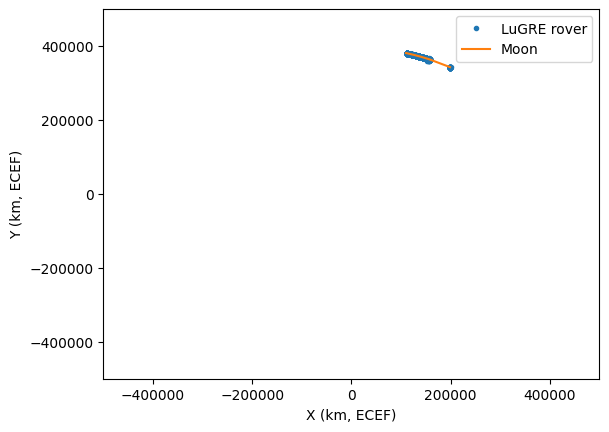

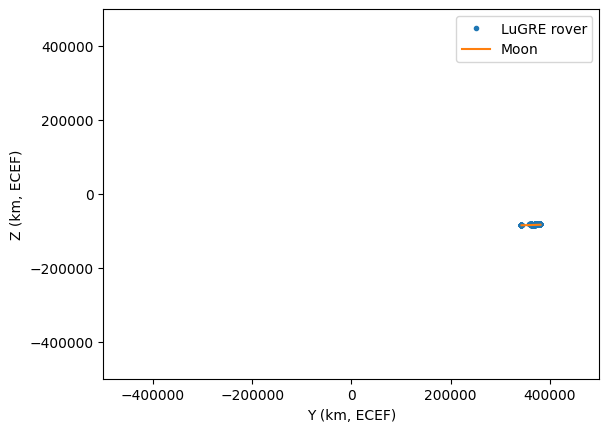

In [62]:
plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,2], '-', label="Moon")
plt.xlabel("X (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,1], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,1], '-', label="Moon")
plt.xlabel("X (km, ECEF)")
plt.ylabel("Y (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,1], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,1], moon_ecef_km[:,2], '-', label="Moon")
plt.xlabel("Y (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

# More moon

In [ ]:
def rover_ecef_to_mcmf_km(rx_ecef_km, t_ast):
    # Convert to meters (lunarsky expects meters)
    coords_m = rx_ecef_km * u.km.to(u.m)

    # Split components
    x = coords_m[:,0] * u.m
    y = coords_m[:,1] * u.m
    z = coords_m[:,2] * u.m


    # Build vectorized ITRS object
    itrs = ITRS(x=x, y=y, z=z, obstime=t_ast)

    # Single transform step (fastest possible)
    mcmf = itrs.transform_to(MCMF(obstime=t_ast))

    # Return km array
    return np.column_stack([
        mcmf.x.to(u.km).value,
        mcmf.y.to(u.km).value,
        mcmf.z.to(u.km).value
    ])

rover_mcmf_km = rover_ecef_to_mcmf_km(rx_ecef_km, utc_times)

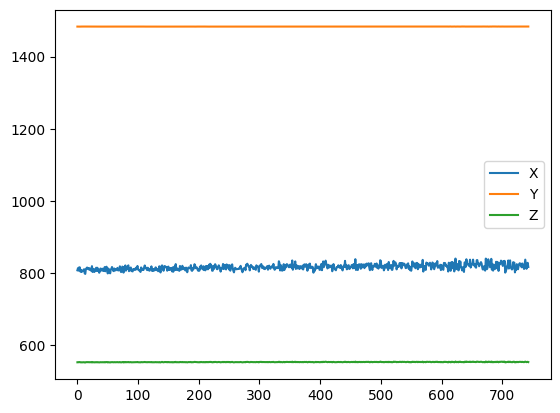

In [87]:
plt.plot(rover_mcmf_km[900:-110], label=["X", "Y", "Z"])
plt.legend()

In [65]:
# rx_tai = np.array([x.timestamp()  for x in Time(t_ast, scale='tai').to_datetime()])
# print(rx_tai)
# rx_mpa = pnt.convert_frame(rx_tai[:-110], rx_ecef_km[:-110] * 1000, pnt.ECEF, pnt.MOON_PA)

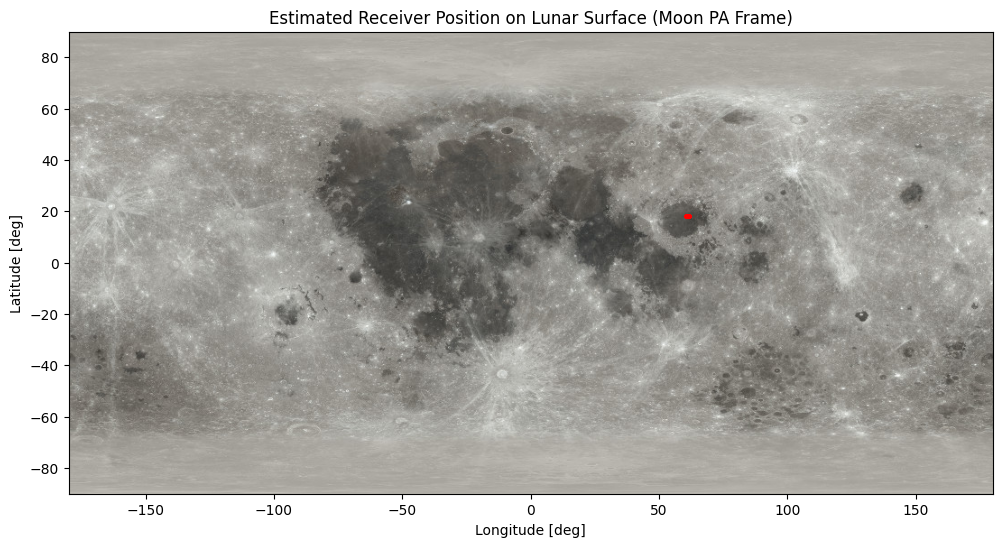

In [84]:
# plot receiver position in Moon PA frame (assert that all positions are on the Moon surface)
if lugre_df["info"]["phase"][0] == 'S':
    fig, ax = plt.subplots(figsize=(12,6))
    # ax.set_xlim(-180,180)
    # ax.set_ylim(-90,90)
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")
    ax.set_title("Estimated Receiver Position on Lunar Surface (Moon PA Frame)")

    # load Moon topography image
    img = plt.imread(pnt.LUPNT_DATA_PATH + "/topo/moon_surface.jpeg")
    # flip image vertically and horizontally
    img = img[::-1, ::-1]
    ax.imshow(img, extent=[-180,180,-90,90], alpha=1)

    for i,pos in enumerate(rover_mcmf_km[900:-110]):
    # for i,pos in enumerate(rover_mcmf_km[900:-110]):
        x, y, z, = pos
        lon = np.degrees(np.arctan2(y, x))
        lat = np.degrees(np.arctan2(z, np.sqrt(x*x + y*y)))
        ax.plot(lon, lat, 'ro', markersize=2)
        # lat, lon, _ = glp.ecef_to_geodetic(pos * 1000)[0]
        # ax.plot(lon, lat, 'ro', markersize=2)
    
    # Export figure to pdf
    plt.savefig("NAV_SurfPos.pdf")

# S3 Satellites

In [99]:
# !wget https://raw.githubusercontent.com/Stanford-NavLab/gnss_lib_py/main/data/unit_test/sp3/COD0MGXFIN_20211180000_01D_05M_ORB.SP3 --quiet -nc -O "data/COD0MGXFIN_20250720000_01D_05M_ORB.SP3"

In [111]:
# get precise ephemeris
# print(rxTime_start)
# print(rxTime_nav[0])
utc_floats_s
sp3_path = glp.load_ephemeris("sp3", gps_time_s * 1000, download_directory="data/ephem")

# sp3 = pnt.SP3Loader(target_dt=utc_start, sim_t=24*3600, dt_timesys=pnt.UTC)
sp3 = glp.Sp3(sp3_path)
# print(sp3)
sat_nums = sorted(list(set(map(str, sp3["gnss_sv_id"]))))
print("SP3 satellites:", sat_nums)

print(sp3)

SP3 satellites: ['C06', 'C07', 'C08', 'C09', 'C10', 'C11', 'C12', 'C13', 'C14', 'C16', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C32', 'C33', 'C34', 'C35', 'C36', 'C37', 'C38', 'C39', 'C40', 'C41', 'C42', 'C43', 'C44', 'C45', 'C48', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E18', 'E19', 'E21', 'E23', 'E24', 'E25', 'E26', 'E27', 'E29', 'E30', 'E31', 'E33', 'E34', 'E36', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32', 'J02', 'J03', 'J04', 'R01', 'R02', 'R03', 'R04', 'R05', 'R07', 'R08', 'R09', 'R11', 'R12', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21', 'R22', 'R24', 'R26']
         gps_millis gnss_sv_id gnss_id  sv_id        x_sv_m        y_sv_m  \
0      1.426118e+12        G01     gps      1  7.994

In [193]:
# get all unique acquired satellites from acq data
ids = []
for index, row in lugre_df["acq"].iterrows():
    prn = int(row['svid'])
    signalId = int(row['signalId'])
    constellation, band = get_const_band(signalId)

    # generate key with leading zeros for prn
    id = f"{constellation}{prn:02d}"
    ids.append(id)

# print("All satellites in ACQ data:", ids)
unique_sats = np.unique(ids)
num_sats = len(unique_sats)
print("Unique satellites in ACQ data:", unique_sats)

# check if all unique satellites are in SP3 data
all_found = True
for key in unique_sats:
    if key not in sat_nums:
        print(f"Warning: Satellite {key} not found in SP3 data.")
        all_found = False
if all_found:
    print("All satellites found in SP3 data!")

Unique satellites in ACQ data: ['E04' 'E06' 'E09' 'E10' 'E11' 'E12' 'E16' 'E23' 'E24' 'E25' 'E31' 'E33'
 'E36' 'G05' 'G11' 'G12' 'G15' 'G19' 'G20' 'G22' 'G25']
All satellites found in SP3 data!


In [323]:
gps_millis = np.array(lugre_df["acq"]["rxTime"] * 1000)

navdata_df = pd.DataFrame()

for time in gps_millis:
    navdata_df = pd.concat([
        navdata_df, pd.DataFrame({"gps_millis": [time] * num_sats, "gnss_sv_id": unique_sats})],
        ignore_index=True)
    
# navdata_df = pd.DataFrame({
#     "gps_millis": np.repeat(gps_millis, len(unique_sats)),
#     "gnss_sv_id": np.tile(unique_sats, len(gps_millis)),
# })

navdata_rows = glp.NavData(pandas_df=navdata_df)
sp3.interpolate_sp3(navdata_rows, window=6)

cropped_sp3 = navdata_rows.where("gps_millis",gps_millis[0],"geq").where("gps_millis",gps_millis[-1],"leq")

In [324]:
# Turn dict of rv_by_sat into numpy array that pnt can plot
rv_sats_sp3 = []
rv_by_sat = defaultdict(list)

for idx, row in cropped_sp3.pandas_df().iterrows():
    rv_by_sat[row['gnss_sv_id']].append(np.array([
        float(row['x_sv_m']),
        float(row['y_sv_m']),
        float(row['z_sv_m'])
    ]))
for sat in unique_sats:
    rv_sats_sp3.append(rv_by_sat[sat])

rv_sats_sp3_Mm = np.array(rv_sats_sp3) / 1e3

In [325]:
# Making NavData dataframe to interpolate S3 data at
# def get_full_sv_ids(lugre_df):
#     ids = []
#     for _, row in lugre_df["acq"].iterrows():
#         prn = int(row['svid'])
#         signalId = int(row['signalId'])
#         constellation, band = get_const_band(signalId)
#         ids.append(f"{constellation}{prn:02d}")
#     return ids


In [327]:
# plot orbits and clock biases
fig = go.Figure()

pnt.plot.plot_body(fig, pnt.EARTH, size_factor=5)
# get position of moon
# e2m_eci = pnt.get_body_pos_vel(tspan_tai, pnt.EARTH, pnt.MOON, pnt.ECI)

orbit_colors = {
    "G": "blue",  # GPS
    "E": "orange",  # GALILEO
    "C": "green",  # BEIDOU
    "R": "purple",  # GLONASS
    "J": "red",  # QZSS
}

gnss_consts = ["G", "E", "C", "R", "J"]  # GPS, GALILEO, BEIDOU, QZSS

# gnss
for gnss_const in gnss_consts:
    sat_idx = [i for i, sat in enumerate(unique_sats) if sat.startswith(gnss_const)]
    pnt.plot.plot_orbits(
        fig, 
        rv_sats_sp3_Mm[sat_idx, :, :], 
        t=0, 
        color=orbit_colors[gnss_const]
    )
# plot moon direction
pnt.plot.plot_arrow3(fig, np.zeros(3), moon_ecef_km[:, :3]/10, length_scale = 1.5, tip_scale = 0.2, color='gray')
pnt.plot.set_view(fig, -80, 20, 2.5)
fig.update_layout(showlegend=True, width=400, height=400)
fig.show()